# CSCI739 Homework 1 — Qiskit verification

Study and verification notebook for Problems 1–5 plus Bonuses A and B, based on the instructor's pinned `Homework 1/main.tex` at `c489b6d29776cb4213d89e0e3d950d26402e7a8a`. Ideal Aer simulation, 1024 shots, fixed seed 739. In written kets qubits are `q0 q1 ...`; Qiskit prints classical strings in reverse register order.

The first code cell prefers the setup helper from the CSCI739 GitHub repository. If GitHub is unavailable (for example, when this notebook is opened from Drive in Colab), it falls back to installing the required pinned packages directly from PyPI. Internet access for package installation is required; GitHub access is optional.

**Run in Google Colab:** use a Python runtime with internet access, then select **Runtime → Run all**.

**Run in VS Code:** open `CSCI739.code-workspace`, choose the course kernel, then **Run All**.

## Environment Setup

In [ ]:
# Prefer the shared Git helper; fall back to direct pinned installs for Drive/Colab copies.
import importlib.util
import subprocess
import sys
from importlib.metadata import version

helper_source = "git+https://github.com/pzg8794/CSCI739.git@main#subdirectory=Homework"
required_packages = [
    "qiskit==2.5.2",
    "qiskit-aer==0.17.2",
    "numpy>=2,<3",
    "matplotlib>=3.9,<4",
]

if importlib.util.find_spec("pip") is None:
    subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"])

try:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", helper_source]
    )
    from qiskit_environment import ensure_environment

    print("Environment ready:", ensure_environment())
except (subprocess.CalledProcessError, ModuleNotFoundError):
    print("GitHub helper unavailable; installing the required packages directly.")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *required_packages]
    )
    print(
        "Environment ready:",
        {
            "qiskit": version("qiskit"),
            "qiskit-aer": version("qiskit-aer"),
            "numpy": version("numpy"),
            "matplotlib": version("matplotlib"),
        },
    )

Environment ready: {'qiskit': '2.5.2', 'qiskit-aer': '0.17.2'}



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


## Problem 1 — single-qubit measurement

For $|+\rangle=(|0\rangle+|1\rangle)/\sqrt2$, compare each amplitude's magnitude with its Born-rule probability. This equal-superposition example does not imply that all qubit states have equal probabilities.

### Solution
The Born rule squares each amplitude's magnitude. Here both amplitudes have magnitude $1/\sqrt2$, so $P(0)=P(1)=1/2$. The plot compares those two quantities.

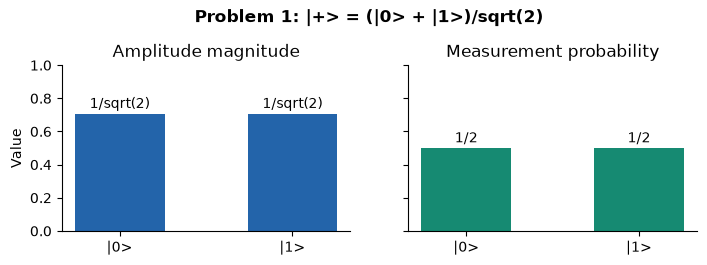

In [81]:
# Homework 1 explanatory plot: Problem 1
# 1. The numerical difference between amplitude and probability.
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 2, figsize=(8.2, 2.55), sharey=True)
for ax, vals, title, color, annotation in (
    (axs[0], [1 / np.sqrt(2)] * 2, "Amplitude magnitude", "#2364aa", "1/sqrt(2)"),
    (axs[1], [0.5] * 2, "Measurement probability", "#168a72", "1/2"),
):
    ax.bar([0, 1], vals, color=color, width=0.52)
    ax.set_xticks([0, 1], ["|0>", "|1>"])
    ax.set_ylim(0, 1)
    ax.set_title(title)
    for x, y in enumerate(vals):
        ax.text(x, y + 0.035, annotation, ha="center")
axs[0].set_ylabel("Value")
fig.suptitle("Problem 1: |+> = (|0> + |1>)/sqrt(2)", fontweight="bold")
fig.subplots_adjust(top=0.76)
plt.show()

### Output

The left panel shows amplitude magnitudes of $1/\sqrt{2}$; the right shows their Born-rule probabilities, $1/2$ each. As the notes emphasize, one measurement returns one outcome.

## Problem 2 — two-qubit CNOT

Track the assignment state in basis order $|00\rangle,|01\rangle,|10\rangle,|11\rangle$ before and after CNOT gates with each qubit as control.

### Solution
Each CNOT permutes basis amplitudes according to its control direction. Squaring their magnitudes gives the displayed probabilities; no amplitudes are combined in this basis-state permutation.

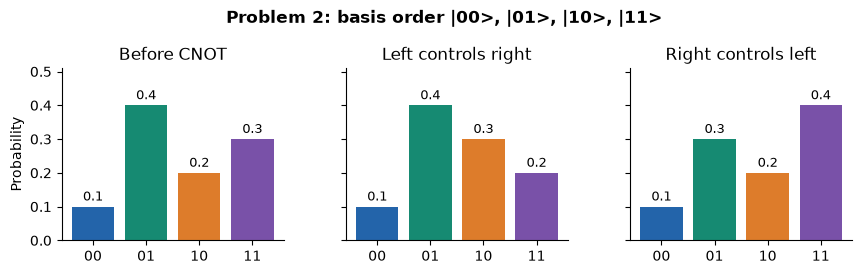

In [ ]:
# Output: shows how each CNOT direction permutes probabilities in the declared basis order.
# Homework 1 explanatory plot: Problem 2
# 2. Basis-order-sensitive probability permutations under the two CNOTs.
basis = ["00", "01", "10", "11"]
states = [
    ("Before CNOT", [0.1, 0.4, 0.2, 0.3]),
    ("Left controls right", [0.1, 0.4, 0.3, 0.2]),
    ("Right controls left", [0.1, 0.3, 0.2, 0.4]),
]
fig, axs = plt.subplots(1, 3, figsize=(10.2, 2.65), sharey=True)
for ax, (title, values) in zip(axs, states):
    ax.bar(basis, values, color=["#2364aa", "#168a72", "#dd7c2b", "#7951a8"])
    ax.set_title(title)
    ax.set_ylim(0, 0.51)
    for i, v in enumerate(values):
        ax.text(i, v + 0.018, f"{v:.1f}", ha="center", fontsize=9)
axs[0].set_ylabel("Probability")
fig.suptitle("Problem 2: basis order |00>, |01>, |10>, |11>", fontweight="bold")
fig.subplots_adjust(top=0.76, wspace=0.28)
plt.show()

### Output

The panels show the original probabilities and the permutations caused by each CNOT control direction, in basis order $|00\rangle,|01\rangle,|10\rangle,|11\rangle$.

## Problem 3 — Bloch sphere and Hadamard

Show the state change when Hadamard acts once and twice on $|0\rangle$.

### Solution
$H|0\rangle=|+\rangle$, and the second Hadamard returns the state to $|0\rangle$. The two contributions to $|0\rangle$ add constructively while those to $|1\rangle$ cancel destructively; the plot shows this path on the Bloch sphere.

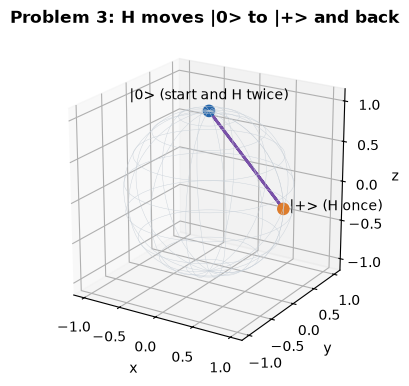

In [ ]:
# Output: shows the Bloch-sphere path |0> -> |+> -> |0> under two Hadamard gates.
# Homework 1 explanatory plot: Problem 3
# 3. Bloch points and repeated-H trajectory.
fig = plt.figure(figsize=(5.8, 4.3))
ax = fig.add_subplot(111, projection="3d")
u = np.linspace(0, 2 * np.pi, 70)
v = np.linspace(0, np.pi, 36)
ax.plot_wireframe(np.outer(np.cos(u), np.sin(v)),
                  np.outer(np.sin(u), np.sin(v)),
                  np.outer(np.ones_like(u), np.cos(v)),
                  color="#c9d1d9", linewidth=0.3, rstride=5, cstride=4)
ax.plot([0, 1, 0], [0, 0, 0], [1, 0, 1], color="#7951a8", linewidth=2)
ax.scatter([0, 1], [0, 0], [1, 0], c=["#2364aa", "#dd7c2b"], s=65, depthshade=False)
ax.text(0, 0, 1.14, "|0> (start and H twice)", ha="center")
ax.text(1.08, 0, 0, "|+> (H once)")
ax.set(xlim=(-1.15, 1.15), ylim=(-1.15, 1.15), zlim=(-1.15, 1.15),
       xlabel="x", ylabel="y", zlabel="z")
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=21, azim=-58)
ax.set_title("Problem 3: H moves |0> to |+> and back", fontweight="bold")
plt.show()

### Output

The sphere traces $|0\rangle\to|+\rangle\to|0\rangle$: the first Hadamard creates the equal superposition, and the second restores $|0\rangle$ through interference.

## Problem 4 — tensor products and CNOT direction

Verify the two- and three-qubit circuit cases, distinguishing H on $q_0$ only from H on all three qubits, and interpret the resulting states and counts.

### Solution
The statevector uses Qiskit's little-endian index convention, so the code displays amplitudes as course-order kets `|q0 q1 ...>`. Measured strings appear in reverse register order, `q2 q1 q0`. The two preparations are checked analytically and with seeded Aer counts.

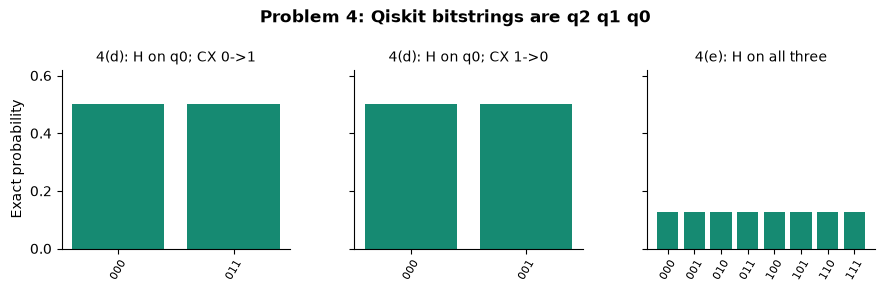

In [ ]:
# Output: compares exact probabilities for the distinct H-on-q0 and H-on-all preparations.
# Homework 1 explanatory plot: Problem 4
# 4. Distinguish the explicitly different preparations in parts (d) and (e).
fig, axs = plt.subplots(1, 3, figsize=(10.5, 2.75), sharey=True)
cases = [
    ("4(d): H on q0; CX 0->1", {"000": 0.5, "011": 0.5}),
    ("4(d): H on q0; CX 1->0", {"000": 0.5, "001": 0.5}),
    ("4(e): H on all three", {f"{i:03b}": 0.125 for i in range(8)}),
]
for ax, (title, data) in zip(axs, cases):
    ax.bar(list(data), list(data.values()), color="#168a72")
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=60, labelsize=8)
    ax.set_ylim(0, 0.62)
axs[0].set_ylabel("Exact probability")
fig.suptitle("Problem 4: Qiskit bitstrings are q2 q1 q0", fontweight="bold")
fig.subplots_adjust(top=0.76, wspace=0.28)
plt.show()

### Output

The bars show exact probabilities for H on $q_0$ only versus H on all three qubits. Labels use Qiskit's $q_2q_1q_0$ bit order.

In [ ]:
# Shared circuit utilities used by the Qiskit problem checks.
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

SHOTS = 1024
SEED = 739

def counts_for(circuit):
    simulator = AerSimulator(seed_simulator=SEED)
    compiled = transpile(circuit, simulator, seed_transpiler=SEED)
    return dict(sorted(simulator.run(compiled, shots=SHOTS).result().get_counts().items()))

def measured_copy(circuit, measured_qubits=None):
    qubits = list(range(circuit.num_qubits)) if measured_qubits is None else list(measured_qubits)
    out = QuantumCircuit(circuit.num_qubits, len(qubits))
    out.compose(circuit, inplace=True)
    for cbit, qubit in enumerate(qubits):
        out.measure(qubit, cbit)
    return out

H on q0 and q1: {'|00>': (0.4999999999999999+0j), '|10>': (0.4999999999999999+0j), '|01>': (0.4999999999999999+0j), '|11>': (0.4999999999999999+0j)}
counts q1q0: {'00': 257, '01': 255, '10': 266, '11': 246}
Case 1, 0->1 {'|000>': (0.7071067811865475+0j), '|110>': (0.7071067811865475+0j)}
  counts q2q1q0: {'000': 521, '011': 503}
Case 2, 1->0 {'|000>': (0.7071067811865475+0j), '|100>': (0.7071067811865475+0j)}
  counts q2q1q0: {'000': 521, '001': 503}
all-H states equal: True
all-H case 1 counts q2q1q0: {'000': 139, '001': 124, '010': 127, '011': 134, '100': 131, '101': 127, '110': 124, '111': 118}
all-H case 2 counts q2q1q0: {'000': 139, '001': 124, '010': 127, '011': 134, '100': 131, '101': 127, '110': 124, '111': 118}


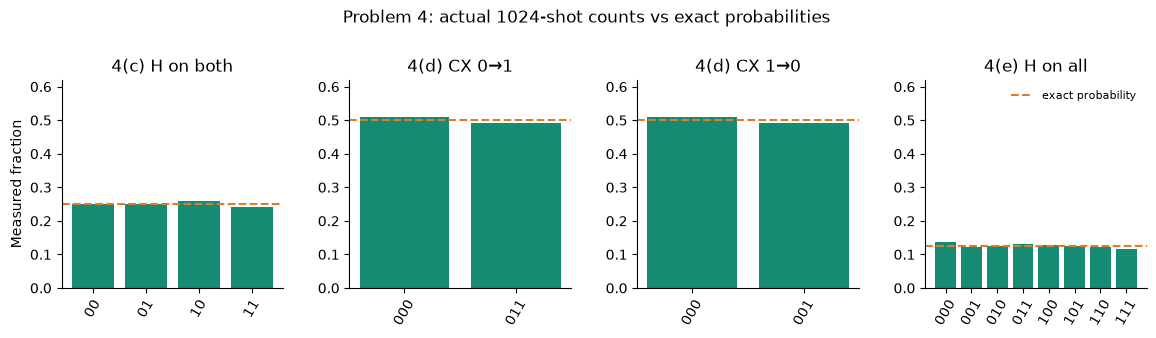

In [ ]:
# Output: prints course-order statevectors and seeded shot counts, then plots measured fractions against exact probabilities.
def course_amplitudes(circuit):
    data = Statevector.from_instruction(circuit).data
    n = circuit.num_qubits
    return {"|" + "".join(str((i >> q) & 1) for q in range(n)) + ">": complex(value)
            for i, value in enumerate(data) if abs(value) > 1e-10}

both_h = QuantumCircuit(2)
both_h.h(0)
both_h.h(1)
print("H on q0 and q1:", course_amplitudes(both_h))
print("counts q1q0:", counts_for(measured_copy(both_h)))

case1 = QuantumCircuit(3)
case1.h(0)
case1.cx(0, 1)
case2 = QuantumCircuit(3)
case2.h(0)
case2.cx(1, 0)
for name, circuit in (("Case 1, 0->1", case1), ("Case 2, 1->0", case2)):
    print(name, course_amplitudes(circuit))
    print("  counts q2q1q0:", counts_for(measured_copy(circuit)))

all_h_01 = QuantumCircuit(3)
all_h_01.h([0, 1, 2])
all_h_01.cx(0, 1)
all_h_10 = QuantumCircuit(3)
all_h_10.h([0, 1, 2])
all_h_10.cx(1, 0)
print("all-H states equal:", Statevector.from_instruction(all_h_01).equiv(Statevector.from_instruction(all_h_10)))
print("all-H case 1 counts q2q1q0:", counts_for(measured_copy(all_h_01)))
print("all-H case 2 counts q2q1q0:", counts_for(measured_copy(all_h_10)))

# Plot measured frequencies from the circuits calculated in this cell.
figure, axes = plt.subplots(1, 4, figsize=(14, 3.2))
plot_cases = [
    ("4(c) H on both", measured_copy(both_h), 0.25),
    ("4(d) CX 0→1", measured_copy(case1), 0.5),
    ("4(d) CX 1→0", measured_copy(case2), 0.5),
    ("4(e) H on all", measured_copy(all_h_01), 0.125),
]
for ax, (title, circuit, exact) in zip(axes, plot_cases):
    observed = counts_for(circuit)
    labels = sorted(observed)
    ax.bar(labels, [observed[k] / SHOTS for k in labels], color="#168a72")
    ax.axhline(exact, color="#dd7c2b", linestyle="--", label="exact probability")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=60)
    ax.set_ylim(0, 0.62)
axes[0].set_ylabel("Measured fraction")
axes[-1].legend(frameon=False, fontsize=8)
figure.suptitle("Problem 4: actual 1024-shot counts vs exact probabilities")
figure.subplots_adjust(top=0.76, wspace=0.3)
plt.show()

### Output

The statevectors report amplitudes in course ket order, while sampled counts print in reverse register order. For $|++\rangle$, each outcome is near $1/4$; the three-qubit cases show the expected CNOT outcomes and finite-shot counts.

## Problem 5 — half and full adders

Implement and check the half- and full-adder circuits, including the specified input traces and the full-adder cases with both values of $C_{in}$.

### Solution
The half-adder computes $S=A\oplus B$ and $C=AB$. The full-adder computes $S=A\oplus B\oplus C_{in}$ and $C_{out}=AB\oplus(A\oplus B)C_{in}$. The two carry terms cannot both be 1, so the XOR gives the usual carry. Only output wires are measured: $S$ maps to $c_0$ and carry to $c_1$, so Qiskit prints `CS`.

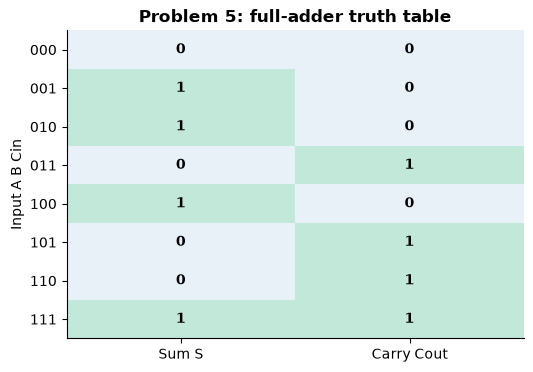

In [ ]:
# Output: displays the full-adder sum/carry truth table; the Cin=0 rows are the half-adder cases.
# Homework 1 explanatory plot: Problem 5
# 5. Complete full-adder truth table (half-adder is the Cin=0 subset).
inputs = [(a, b, cin) for a in (0, 1) for b in (0, 1) for cin in (0, 1)]
outputs = np.array([[(a ^ b ^ cin), ((a & b) | ((a ^ b) & cin))]
                    for a, b, cin in inputs])
fig, ax = plt.subplots(figsize=(5.9, 4.0))
ax.imshow(outputs, cmap=plt.matplotlib.colors.ListedColormap(["#e8f0f8", "#c2e8da"]),
          vmin=0, vmax=1, aspect="auto")
ax.set_xticks([0, 1], ["Sum S", "Carry Cout"])
ax.set_yticks(range(8), [f"{a}{b}{cin}" for a, b, cin in inputs])
ax.set_ylabel("Input A B Cin")
for row in range(8):
    for col in range(2):
        ax.text(col, row, str(outputs[row, col]), ha="center", va="center", fontweight="bold")
ax.set_title("Problem 5: full-adder truth table", fontweight="bold")
plt.show()

### Output

The table lists $S=A\oplus B\oplus C_{in}$ and the carry for all eight inputs. The four $C_{in}=0$ rows are the half-adder cases.

Half trace |110> -> {'|101>': (1+0j)}
Full trace |1100> -> {'|1101>': (1+0j)}
A=0 B=0 Cin=0: half CS={'00': 1024}; full CS={'00': 1024}
A=0 B=1 Cin=0: half CS={'01': 1024}; full CS={'01': 1024}
A=1 B=0 Cin=0: half CS={'01': 1024}; full CS={'01': 1024}
A=1 B=1 Cin=0: half CS={'10': 1024}; full CS={'10': 1024}
extra check A=0 B=0 Cin=1: full CS={'01': 1024}
extra check A=0 B=1 Cin=1: full CS={'10': 1024}
extra check A=1 B=0 Cin=1: full CS={'10': 1024}
extra check A=1 B=1 Cin=1: full CS={'11': 1024}


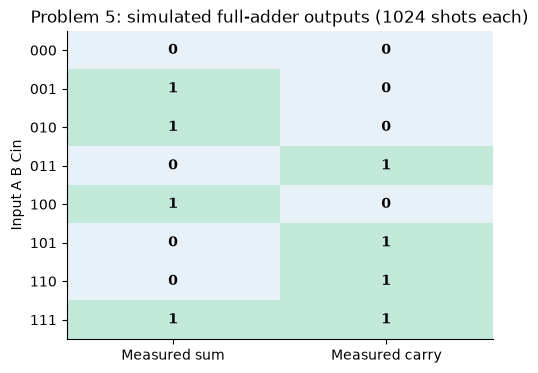

In [ ]:
# Output: prints deterministic ideal counts for half/full adders, checks Cin=1, and plots measured sum/carry bits.
def half_adder(a, b):
    circuit = QuantumCircuit(3)
    if a: circuit.x(0)
    if b: circuit.x(1)
    circuit.ccx(0, 1, 2)
    circuit.cx(0, 1)
    return circuit

def full_adder(a, b, cin):
    circuit = QuantumCircuit(4)
    if a: circuit.x(0)
    if b: circuit.x(1)
    if cin: circuit.x(2)
    circuit.ccx(0, 1, 3)
    circuit.cx(0, 1)
    circuit.ccx(1, 2, 3)
    circuit.cx(1, 2)
    circuit.cx(0, 1)
    return circuit

print("Half trace |110> ->", course_amplitudes(half_adder(1, 1)))
print("Full trace |1100> ->", course_amplitudes(full_adder(1, 1, 0)))
for a in (0, 1):
    for b in (0, 1):
        h = half_adder(a, b)
        f = full_adder(a, b, 0)
        hc = counts_for(measured_copy(h, [1, 2]))
        fc = counts_for(measured_copy(f, [2, 3]))
        expected = f"{a & b}{a ^ b}"
        assert hc == {expected: SHOTS} and fc == {expected: SHOTS}
        print(f"A={a} B={b} Cin=0: half CS={hc}; full CS={fc}")

for a in (0, 1):
    for b in (0, 1):
        f = full_adder(a, b, 1)
        fc = counts_for(measured_copy(f, [2, 3]))
        expected = f"{(a & b) | ((a ^ b) & 1)}{a ^ b ^ 1}"
        assert fc == {expected: SHOTS}
        print(f"extra check A={a} B={b} Cin=1: full CS={fc}")

# Plot the actual deterministic output bits read from all eight full-adder cases.
full_cases = [(a, b, cin) for a in (0, 1) for b in (0, 1) for cin in (0, 1)]
measured_bits = []
for a, b, cin in full_cases:
    result = counts_for(measured_copy(full_adder(a, b, cin), [2, 3]))
    assert len(result) == 1 and next(iter(result.values())) == SHOTS
    carry_sum = next(iter(result))  # Qiskit displays c1c0 = carry, sum.
    measured_bits.append([int(carry_sum[1]), int(carry_sum[0])])
measured_bits = np.array(measured_bits)
figure, ax = plt.subplots(figsize=(5.5, 4))
ax.imshow(measured_bits, cmap=plt.matplotlib.colors.ListedColormap(["#e8f0f8", "#c2e8da"]), vmin=0, vmax=1, aspect="auto")
ax.set_xticks([0, 1], ["Measured sum", "Measured carry"])
ax.set_yticks(range(8), [f"{a}{b}{cin}" for a, b, cin in full_cases])
ax.set_ylabel("Input A B Cin")
for row in range(8):
    for col in range(2):
        ax.text(col, row, str(measured_bits[row, col]), ha="center", va="center", fontweight="bold")
ax.set_title("Problem 5: simulated full-adder outputs (1024 shots each)")
plt.show()

### Output

The traces give $|101\rangle$ for the half-adder input $|110\rangle$ and $|1101\rangle$ for the full-adder input $|1100\rangle$. The counts verify the sum/carry outputs; Qiskit prints `CS` because $c_1=C$ and $c_0=S$.

## Bonus A — Hamiltonian evolution as an X gate

Check the matrix solution to Schrödinger's equation and verify that $H=\hbar\Omega X$ with $\Omega=\pi/2$ swaps the amplitudes over $0\le t\le1$.

### Solution
With $\hbar=1$, the evolution is $U(t)=\cos(\Omega t)I-i\sin(\Omega t)X$. The code checks the differential equation, unitarity, the endpoint $U(1)=-iX$, and normalization. The global phase does not affect measurement probabilities.

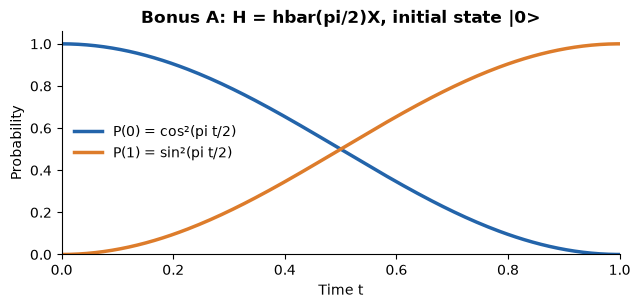

In [ ]:
# Output: plots P(0)=cos^2(pi t/2) and P(1)=sin^2(pi t/2) for evolution from |0>.
# Homework 1 explanatory plot: Bonus A
# Bonus A. An X rotation generated by a constant Hamiltonian.
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(7.2, 2.9))
ax.plot(t, np.cos(np.pi * t / 2) ** 2, label="P(0) = cos²(pi t/2)", color="#2364aa", lw=2.5)
ax.plot(t, np.sin(np.pi * t / 2) ** 2, label="P(1) = sin²(pi t/2)", color="#dd7c2b", lw=2.5)
ax.set(xlabel="Time t", ylabel="Probability", xlim=(0, 1), ylim=(0, 1.06))
ax.legend(frameon=False, loc="center left")
ax.set_title("Bonus A: H = hbar(pi/2)X, initial state |0>", fontweight="bold")
plt.show()

### Output

The curves show probability transfer from $|0\rangle$: $P(0)=\cos^2(\pi t/2)$ decreases to zero while $P(1)=\sin^2(\pi t/2)$ increases to one.

U(1) = [[6.123234e-17+0.j 0.000000e+00-1.j]
 [0.000000e+00-1.j 6.123234e-17+0.j]]
sample initial amplitudes = [0.54772256+0.j         0.        +0.83666003j]
sample final amplitudes = [0.83666003+0.j         0.        -0.54772256j]
final probabilities (0, 1) = [0.7 0.3]
norm = 1.0


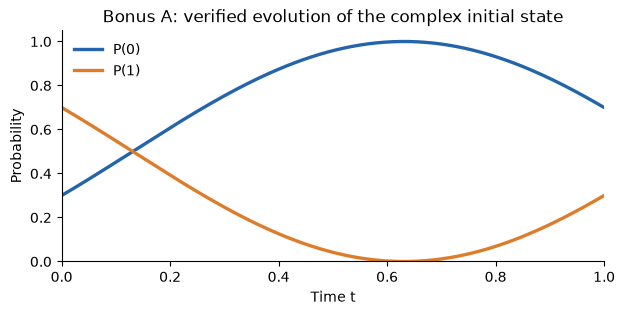

In [ ]:
# Output: prints U(1), initial/final amplitudes, probabilities and norm, then plots the probability evolution.
import numpy as np
import matplotlib.pyplot as plt

Xmat = np.array([[0, 1], [1, 0]], dtype=complex)
I2 = np.eye(2, dtype=complex)
Omega = np.pi / 2

def evolution(t):
    return np.cos(Omega * t) * I2 - 1j * np.sin(Omega * t) * Xmat

def evolution_derivative(t):
    return -Omega * np.sin(Omega * t) * I2 - 1j * Omega * np.cos(Omega * t) * Xmat

for t in (0.0, 0.37, 1.0):
    U = evolution(t)
    assert np.allclose(U.conj().T @ U, I2)
    assert np.allclose(1j * evolution_derivative(t), Omega * Xmat @ U)

psi0 = np.array([np.sqrt(0.3), 1j * np.sqrt(0.7)])
psi1 = evolution(1.0) @ psi0
assert np.allclose(evolution(1.0), -1j * Xmat)
assert np.allclose(psi1, -1j * np.array([psi0[1], psi0[0]]))
assert np.isclose(np.sum(np.abs(psi1)**2), 1.0)
print("U(1) =", evolution(1.0))
print("sample initial amplitudes =", psi0)
print("sample final amplitudes =", psi1)
print("final probabilities (0, 1) =", np.abs(psi1)**2)
print("norm =", np.sum(np.abs(psi1)**2))

# Plot the probability transfer for the complex initial state tested above.
times = np.linspace(0, 1, 201)
probabilities = np.array([np.abs(evolution(t) @ psi0) ** 2 for t in times])
assert np.allclose(probabilities.sum(axis=1), 1)
figure, ax = plt.subplots(figsize=(7, 3))
ax.plot(times, probabilities[:, 0], label="P(0)", color="#2364aa", lw=2.4)
ax.plot(times, probabilities[:, 1], label="P(1)", color="#dd7c2b", lw=2.4)
ax.set(xlabel="Time t", ylabel="Probability", xlim=(0, 1), ylim=(0, 1.05))
ax.legend(frameon=False)
ax.set_title("Bonus A: verified evolution of the complex initial state")
plt.show()

### Output

The checks confirm $U(1)=-iX$, so the amplitudes swap up to a global phase and the norm stays $1$. For the sample state, the final probabilities are $(0.7,0.3)$; the curves show their continuous evolution.

## Bonus B — two-bit ripple-carry adder, 2 + 2

Build a genuine two-stage ripple-carry adder and verify the assigned $2+2$ case. The qubits are `q0=a0`, `q1=a1`, `q2=b0`, `q3=b1`, `q4=carry from bit 0 / later s1`, and `q5=final carry`.

### Solution
The low stage is the Problem 5 half adder on `(q0,q2,q4)`; the high stage is the full adder on `(q1,q3,q4,q5)`. Measure `q2→c0=s0`, `q4→c1=s1`, and `q5→c2=c_out`. Qiskit prints `c2c1c0`, so $2+2$ is `100`.

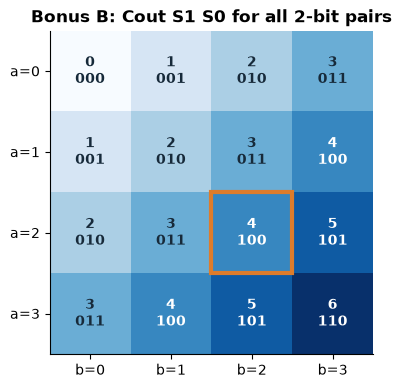

In [ ]:
# Output: shows decimal and binary sums for all two-bit input pairs and highlights 2+2=100_2.
# Bonus B. Full 2-bit addition table; the assigned 2+2 case is highlighted.
import numpy as np
import matplotlib.pyplot as plt

grid = np.add.outer(np.arange(4), np.arange(4))
fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.imshow(grid, cmap="Blues", vmin=0, vmax=6)
ax.set_xticks(range(4), [f"b={i}" for i in range(4)])
ax.set_yticks(range(4), [f"a={i}" for i in range(4)])
for a in range(4):
    for b in range(4):
        val = a + b
        label = f"{val}\n{val:03b}"
        ax.text(b, a, label, ha="center", va="center",
                color="white" if val >= 4 else "#172a3a", fontweight="bold")
ax.add_patch(plt.Rectangle((1.5, 1.5), 1, 1, fill=False, edgecolor="#dd7c2b", lw=3))
ax.set_title("Bonus B: Cout S1 S0 for all 2-bit pairs", fontweight="bold")
plt.show()

### Output

Each grid entry shows the sum in decimal and binary; the orange outline marks the assigned $2+2=4=100_2$ case.

all 16 two-bit input pairs match ordinary addition
2+2 final written ket q0...q5: {'|010101>': (1+0j)}
2+2 measured c_out s1 s0: {'100': 1024}


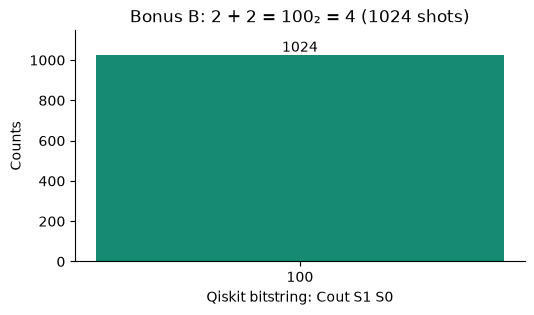

In [ ]:
# Output: verifies all 16 input pairs, prints the 2+2 state/counts as c_out s1 s0=100, and plots the measured result.
def ripple2(a, b):
    circuit = QuantumCircuit(6)
    for bit, qubit in ((a & 1, 0), ((a >> 1) & 1, 1),
                       (b & 1, 2), ((b >> 1) & 1, 3)):
        if bit:
            circuit.x(qubit)
    # Low bit: half adder. q2 becomes s0; q4 becomes the carry into bit 1.
    circuit.ccx(0, 2, 4)
    circuit.cx(0, 2)
    # High bit: full adder. q4 becomes s1; q5 becomes c_out.
    circuit.ccx(1, 3, 5)
    circuit.cx(1, 3)
    circuit.ccx(3, 4, 5)
    circuit.cx(3, 4)
    circuit.cx(1, 3)
    return circuit

# Independently check all 16 two-bit input pairs by statevector.
for a in range(4):
    for b in range(4):
        data = Statevector.from_instruction(ripple2(a, b)).data
        populated = np.flatnonzero(np.abs(data) > 1e-10)
        assert len(populated) == 1 and np.isclose(abs(data[populated[0]]), 1.0)
        index = int(populated[0])
        s0, s1, cout = ((index >> q) & 1 for q in (2, 4, 5))
        assert s0 + 2*s1 + 4*cout == a + b
print("all 16 two-bit input pairs match ordinary addition")

# Required case, 2 = 10_2: least-significant bits a0=b0=0,
# most-significant bits a1=b1=1.
add_2_plus_2 = ripple2(2, 2)
print("2+2 final written ket q0...q5:", course_amplitudes(add_2_plus_2))
print("2+2 measured c_out s1 s0:", counts_for(measured_copy(add_2_plus_2, [2, 4, 5])))
assert counts_for(measured_copy(add_2_plus_2, [2, 4, 5])) == {"100": SHOTS}

# Plot the measured output of the required 2+2 circuit, with bit meaning explicit.
measured_2_plus_2 = counts_for(measured_copy(add_2_plus_2, [2, 4, 5]))
figure, ax = plt.subplots(figsize=(5.8, 3))
ax.bar(list(measured_2_plus_2), list(measured_2_plus_2.values()), color="#168a72", width=0.5)
ax.set(xlabel="Qiskit bitstring: Cout S1 S0", ylabel="Counts", ylim=(0, SHOTS * 1.12))
for label, count in measured_2_plus_2.items():
    ax.text(label, count + 18, str(count), ha="center")
ax.set_title("Bonus B: 2 + 2 = 100₂ = 4 (1024 shots)")
plt.show()

### Output

The statevector checks all 16 input pairs against ordinary addition. The required circuit measures `c_out s1 s0 = 100` exactly 1024 times, which is decimal 4.

## Conclusion

### Findings
The ideal simulations show no mismatch in the checked cases: Born-rule probabilities, circuit mappings, and Qiskit bit order match expectations. The ripple adder matches ordinary addition for all 16 pairs, including `2 + 2 = 100`. Bonus A gives $U(1)=-iX$ and preserves normalization.

### Reference
The [Homework 1 answer PDF on GitHub](https://github.com/pzg8794/CSCI739/blob/main/Homework_1-Submission-Version.pdf) provides the fuller written derivations behind these notebook checks. [Local PDF copy](Homework_1-Submission-Version.pdf).

These are ideal Aer simulation results, not hardware measurements.